In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [4]:
from src.env.board import (
    load_words,
    BoardConfig,
    make_standard_config,
    generate_board,
    summarize_roles,
    print_board_roles,
    board_role_table,
    reveal_cell_by_index,
    all_good_revealed,
)
from src.env.visualization import plot_board
from src.agents.random_agent import RandomAgent

{'good': 3, 'neutral': 5, 'bomb': 1}
Board role mapping:
(0,0) SNOWMAN: bomb | (0,1) HOLE: good | (0,2) CYCLE: neutral
(1,0) DECK: neutral | (1,1) BUG: neutral | (1,2) PUPIL: neutral
(2,0) PHOENIX: good | (2,1) MOUNT: good | (2,2) SOLDIER: neutral


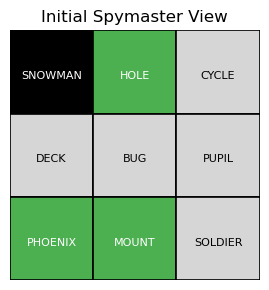

In [5]:
words = load_words(PROJECT_ROOT / "data" / "raw" / "codenames_words.txt")

board = generate_board(words, make_standard_config(3, 3, seed=None))

print(summarize_roles(board))
print_board_roles(board)
plot_board(board, reveal_roles=True, title="Initial Spymaster View")

Guess #9: FACE -> bomb


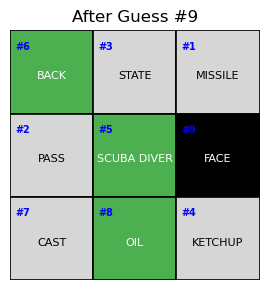

Bomb selected. Stop.


In [ ]:
from IPython.display import clear_output
import time

board = generate_board(words, make_standard_config(3, 3, seed=None))
agent = RandomAgent(seed=None)

print("Initial hidden board:")
plot_board(board, reveal_roles=False, reveal_revealed_only=True, title="Initial Board")

while True:
    available = [cell for row in board for cell in row if not cell.revealed]
    if not available:
        print("No more available cells. Stop.")
        break

    action = agent.select_action(board)
    chosen_cell = reveal_cell_by_index(board, action)

    clear_output(wait=True)

    print(f"Guess #{chosen_cell.guess_order}: {chosen_cell.word} -> {chosen_cell.role}")

    plot_board(
        board,
        reveal_roles=False,
        reveal_revealed_only=True,
        title=f"After Guess #{chosen_cell.guess_order}",
    )

    time.sleep(1)

    if chosen_cell.role == "bomb":
        print("Bomb selected. Stop.")
        break

    if all_good_revealed(board):
        print("All good words revealed. Success. Stop.")
        break